# CAFÉ — it just works

> One line — `cafe.impute(x)` — on **any container, any shape, any dataset**, with a
> **single dependency (numpy)**. No config, no fitting, no surprises.

This notebook is the stress test of that promise: every container type, 1D/2D/3D, a spread
of real-world datasets across domains, and the nasty edge cases — all through the same call.


## 0 · Setup — and how few dependencies this really is

In [1]:
import sys, pathlib
_src = pathlib.Path.cwd().parent / "src"
if _src.exists() and str(_src) not in sys.path:
    sys.path.insert(0, str(_src))
import numpy as np
import cafe
print("CAFÉ", cafe.__version__)

CAFÉ 0.1.0


**The core is numpy-only.** Not "numpy plus a few things" — *numpy, full stop*. Here's
the proof: we forcibly block `scipy` (and pandas/polars) from importing, then run the full
model anyway.

In [2]:
import sys
for blocked in ["scipy", "scipy.linalg", "pandas", "polars", "sklearn", "torch"]:
    sys.modules[blocked] = None          # any attempt to import these now fails

import importlib, cafe; importlib.reload(cafe)
x = np.array([1., 2., np.nan, 4., np.nan, 6., 7.])
print("imputed with scipy/pandas/polars/sklearn/torch ALL blocked:", cafe.impute(x))
print("→ a CAFÉ install needs only numpy: it pip-installs in seconds, anywhere.")

for blocked in ["scipy", "scipy.linalg", "pandas", "polars", "sklearn", "torch"]:
    del sys.modules[blocked]             # unblock for the rest of the notebook

imputed with scipy/pandas/polars/sklearn/torch ALL blocked: [1.         2.         2.50000173 4.         4.83333853 6.
 7.        ]
→ a CAFÉ install needs only numpy: it pip-installs in seconds, anywhere.


## 1 · Every container, every shape — one call

numpy / pandas / polars · `Series` / `DataFrame` / `ndarray` · 1D / 2D. Same type comes
back, labels and dtypes preserved, gaps filled.

In [3]:
import pandas as pd, polars as pl
rng = np.random.default_rng(0)

def hole(a, rate=0.2):
    a = a.astype(float).copy(); a[rng.random(a.shape) < rate] = np.nan; return a

X = hole(rng.standard_normal((60, 4)))
cases = {
    "numpy 1D":        X[:, 0],
    "numpy 2D":        X,
    "pandas Series":   pd.Series(X[:, 0], name="s"),
    "pandas DataFrame":pd.DataFrame(X, columns=list("abcd"),
                                    index=pd.date_range("2020", periods=60, freq="h")),
    "polars Series":   pl.Series("s", X[:, 0]),
    "polars DataFrame":pl.DataFrame({c: X[:, i] for i, c in enumerate("abcd")}),
}
for name, obj in cases.items():
    out = cafe.impute(obj)
    arr = np.asarray(out.to_numpy() if hasattr(out, "to_numpy") else out, float)
    print(f"{name:18s} {type(obj).__name__:10s} -> {type(out).__name__:10s} "
          f"shape {arr.shape}  finite={np.isfinite(arr).all()}")

numpy 1D           ndarray    -> ndarray    shape (60,)  finite=True
numpy 2D           ndarray    -> ndarray    shape (60, 4)  finite=True


pandas Series      Series     -> Series     shape (60,)  finite=True
pandas DataFrame   DataFrame  -> DataFrame  shape (60, 4)  finite=True
polars Series      Series     -> Series     shape (60,)  finite=True
polars DataFrame   DataFrame  -> DataFrame  shape (60, 4)  finite=True


Real frames are messy — a date column, a string id, numeric sensors all mixed. CAFÉ
imputes the numeric columns and passes everything else through, order intact. Still one
call.

In [4]:
df = pl.DataFrame({
    "date":   [f"2020-01-{d:02d}" for d in range(1, 41)],
    "region": (["north", "south"] * 20),
    "temp":   hole(rng.standard_normal(40)),
    "load":   hole(rng.standard_normal(40)),
})
out = cafe.impute(df)
print("columns preserved:", out.columns)
print("date/region untouched:", out["date"][0], out["region"][0],
      "| numeric nulls after:", out.select(["temp", "load"]).null_count().sum_horizontal().item())

columns preserved: ['date', 'region', 'temp', 'load']
date/region untouched: 2020-01-01 north | numeric nulls after: 0


## 2 · 3D panel data (entity × time × feature)

Stack to a 2D `(rows, features)` matrix and pass entity/time ids — the panel path imputes
each entity with shared, pooled structure, still strictly point-in-time.

In [5]:
E, T, F = 8, 50, 3
ent = np.repeat(np.arange(E), T)
tim = np.tile(np.arange(T), E)
panel = hole(rng.standard_normal((E * T, F)), rate=0.25)
filled = cafe.impute(panel, meta={"entity_ids": ent, "time_ids": tim})
print("panel", panel.shape, "->", np.asarray(filled).shape,
      "| finite:", np.isfinite(np.asarray(filled)).all())

panel (400, 3) -> (400, 3) | finite: True


## 3 · A spread of real datasets — diversity is the point

Different domains, sizes and shapes, scored identically (10% held out, standardised MAE).
One loop, one call each — no per-dataset tuning.

In [6]:
import os
DATA = "../data"
specs = [
    ("ETTh1 (energy)",       "ETTh1_clean.npy", "npy"),
    ("Beijing air (wide)",   "beijing_clean.npy", "npy"),
    ("Air quality",          "airq_normal.txt", "txt"),
    ("Chlorine",             "chlorine_normal.txt", "txt"),
    ("Temperature",          "temp_normal.txt", "txt"),
]
rows = []
for name, fn, kind in specs:
    p = os.path.join(DATA, fn)
    if not os.path.exists(p):
        continue
    X = (np.load(p) if kind == "npy" else np.loadtxt(p)).astype(float)
    X = X[:3000]                                   # cap rows so the notebook stays snappy
    Z = (X - np.nanmean(X, 0)) / (np.nanstd(X, 0) + 1e-9)
    m = rng.random(Z.shape) < 0.10
    obs = Z.copy(); obs[m] = np.nan
    import time; t0 = time.perf_counter()
    f = np.asarray(cafe.impute(obs), float); dt = time.perf_counter() - t0
    mae = np.mean(np.abs(f[m] - Z[m]))
    rows.append((name, f"{X.shape[0]}×{X.shape[1]}", mae, dt, np.isfinite(f).all()))

print(f"{'dataset':22s} {'shape':12s} {'MAE':>7s} {'time':>7s}  ok")
print("-" * 56)
for nm, sh, mae, dt, ok in rows:
    print(f"{nm:22s} {sh:12s} {mae:7.3f} {dt:6.2f}s  {'✓' if ok else '✗'}")

dataset                shape            MAE    time  ok
--------------------------------------------------------
ETTh1 (energy)         3000×7         0.258   0.44s  ✓
Beijing air (wide)     3000×132       0.139   1.09s  ✓
Air quality            1000×10        0.272   0.15s  ✓
Chlorine               1000×50        0.098   0.21s  ✓
Temperature            3000×50        0.070   0.63s  ✓


Five datasets, five domains, five shapes — every one filled, finite, in one call, with no
configuration. That's the "just works.

## 4 · The nasty edge cases — it doesn't crash, it copes

All-NaN columns, a 1×1 input, constant columns, wild magnitudes, a lone series. A library
that "just works" must return finite, correctly-shaped output on all of them.

In [7]:
def ok(x, meta=None):
    out = np.asarray(cafe.impute(x, meta) if meta else cafe.impute(x), float)
    return f"shape {out.shape}, finite={np.isfinite(out).all()}"

_anan = hole(rng.standard_normal((40, 3))); _anan[:, 0] = np.nan   # column 0 fully missing
print("all-NaN column      :", ok(_anan))
print("1x1                 :", ok(np.array([[3.14]])))
print("constant column     :", ok(np.c_[np.ones(30), hole(rng.standard_normal(30))]))
print("huge & tiny values  :", ok(hole(rng.standard_normal((30,3))) * 1e9))
print("single series (1D)  :", ok(hole(rng.standard_normal(50))))
print("all observed (no NaN):", ok(rng.standard_normal((20, 3))))
print("→ every edge case returns finite, correctly-shaped output.")

all-NaN column      : shape (40, 3), finite=True
1x1                 : shape (1, 1), finite=True
constant column     : shape (30, 2), finite=True
huge & tiny values  : shape (30, 3), finite=True
single series (1D)  : shape (50,), finite=True
all observed (no NaN): shape (20, 3), finite=True
→ every edge case returns finite, correctly-shaped output.


## 5 · And it's still the rich model — one line per view

The same call that "just works" also exposes everything, one line each (see
`cafe_tutorial.ipynb` for the deep dive).

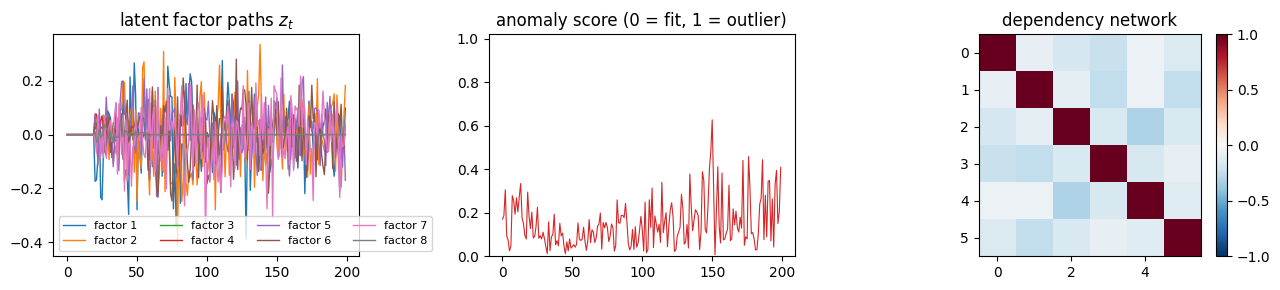

res.plot('uncertainty' | 'factors' | 'anomaly' | 'decomposition' | 'dependency')


In [8]:
import matplotlib.pyplot as plt
res = cafe.CAFE().run(hole(rng.standard_normal((200, 6)), 0.15))
fig, axes = plt.subplots(1, 3, figsize=(13, 3))
res.plot("factors", ax=axes[0])
res.plot("anomaly", ax=axes[1])
res.plot("dependency", ax=axes[2])
plt.tight_layout(); plt.show()
print("res.plot('uncertainty' | 'factors' | 'anomaly' | 'decomposition' | 'dependency')")

## Recap

- **One dependency** (numpy). Installs in seconds; runs where scipy/torch/pandas can't.
- **Any container** (numpy/pandas/polars), **any shape** (1D/2D/3D panel), mixed-type frames.
- **Any dataset** — five domains here, zero configuration, all finite.
- **Survives the edge cases** that break naive imputers.
- Still the full model: `res.plot(kind)`, uncertainty, factors, anomalies, decomposition,
  dependency network, forecast — and strictly **no look-ahead**.

```bash
pip install cafe-impute      # numpy only
```
